# Configuration

In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import gc
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [2]:
# Set up Random SEED
SEED = 100
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load Stock Data

In [3]:
# Complete Dataset for all stocks
stocks = pd.read_csv("../data/features/complete_features.csv")
stocks

,date,open,high,low,close,volume,symbol,log_return,next_day_return,return_lag_1,...,volume_ratio_10_scaled,avg_volume_20_scaled,volume_ratio_20_scaled,vwap_5_scaled,price_to_vwap_scaled,obv_scaled,obv_ema_scaled,daily_range_scaled,close_to_high_scaled,close_to_low_scaled
0,2020-03-16,58.572813,62.719751,58.100745,58.635757,322423600,AAPL,-0.137708,0.043031,0.113157,...,0.595175,4.233130,1.064049,-1.858993,-3.864970,-3.576880,-3.077460,4.614803,5.028490,-0.003524
1,2020-03-17,59.918818,62.363889,57.713410,61.213982,324056000,AAPL,0.043031,-0.024785,-0.137708,...,0.608192,4.437254,0.957513,-1.888406,-1.131564,-3.148609,-3.116756,4.697356,0.988784,4.412220
2,2020-03-18,58.045074,60.521618,57.403543,59.715469,300233600,AAPL,-0.024785,-0.007692,0.043031,...,0.236891,4.682702,0.550711,-1.911668,-1.437466,-3.545397,-3.224429,2.688008,0.545778,2.663003
3,2020-03-19,59.889773,61.209143,58.732600,59.257927,271857200,AAPL,-0.007692,-0.065590,-0.024785,...,-0.167925,4.886548,0.142506,-1.911937,-1.759107,-3.904682,-3.380907,1.758172,2.151910,-0.026182
4,2020-03-20,59.838923,60.964627,55.195707,55.495895,401693200,AAPL,-0.065590,-0.021473,-0.007692,...,1.018300,5.210408,1.347048,-1.971475,-2.554388,-4.435557,-3.609976,6.529063,7.156550,-0.327091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6030,2024-12-23,431.000000,434.510010,415.410004,430.600006,72698100,TSLA,0.022404,0.070991,-0.035257,...,-0.991649,-0.237916,-0.425982,2.647402,-0.584714,1.249207,1.250505,0.117043,-0.319123,0.687298
6031,2024-12-24,435.899994,462.779999,435.140015,462.279999,59551800,TSLA,0.070991,-0.017787,0.022404,...,-1.329250,-0.274356,-0.834958,2.563200,1.117838,1.264048,1.252393,0.793948,-0.653420,1.731414
6032,2024-12-26,465.160004,465.329987,451.019989,454.130005,76366400,TSLA,-0.017787,-0.050745,0.070991,...,-0.729346,-0.260246,-0.267188,2.582779,0.682551,1.245016,1.250512,-0.432885,0.317122,-0.513262
6033,2024-12-27,449.519989,450.000000,426.500000,431.660004,82666800,TSLA,-0.050745,-0.033569,-0.017787,...,-0.510392,-0.235408,-0.087805,2.573317,-0.274182,1.224414,1.245265,0.469019,1.021610,-0.302735


In [4]:
"""
Create final feature matrix (X) and target vector (y) for each stock.

Args:
    df: DataFrame with all features
    use_scaled: Whether to use scaled features (default True)

Returns:
    Dictionary with stock symbols as keys, containing X, y, and dates
"""
def create_feature_matrix(df, use_scaled=True):
    # Identify feature columns
    exclude_cols = ['date', 'symbol', 'next_day_return']
    
    if use_scaled:
        # Use only scaled features
        feature_cols = [col for col in df.columns if col.endswith('_scaled')]
    else:
        # Use original features
        feature_cols = [col for col in df.columns if col not in exclude_cols and not col.endswith('_scaled')]
    
    # Target variable
    target_col = 'next_day_return'
    
    stock_data = {}
    
    for symbol in df['symbol'].unique():
        stock_df = df[df['symbol'] == symbol].copy()
        stock_df = stock_df.sort_values('date')
        
        # Remove rows with missing target or features
        valid_mask = (
            stock_df[target_col].notnull() & 
            stock_df[feature_cols].notnull().all(axis=1)
        )
        
        stock_df_clean = stock_df[valid_mask].copy()
        
        # Create X and y
        X = stock_df_clean[feature_cols].values
        y = stock_df_clean[target_col].values
        dates = stock_df_clean['date'].values
        
        stock_data[symbol] = {
            'X': X,
            'y': y,
            'dates': pd.to_datetime(dates),
            'feature_names': feature_cols,
            'n_samples': len(X),
            'n_features': len(feature_cols)
        }
    
    return stock_data

In [5]:
stock_matrices = create_feature_matrix(df=stocks)
stock_matrices['TSLA']['X']

array([[-2.34938079, -2.35524293, -2.32734656, ...,  2.94205286,
         3.54953368, -0.52689653],
       [-2.37337249, -2.37373696, -2.36536535, ...,  5.73423565,
         3.02758844,  2.70223437],
       [-2.41487187, -2.42755607, -2.40282418, ...,  4.32645849,
         3.85173037,  0.44408558],
       ...,
       [ 2.58807721,  2.82407732,  2.68330043, ...,  0.7939483 ,
        -0.6534201 ,  1.73141394],
       [ 2.9451461 ,  2.85480685,  2.87944634, ..., -0.43288457,
         0.31712237, -0.51326158],
       [ 2.7542862 ,  2.67006743,  2.57658089, ...,  0.46901868,
         1.0216101 , -0.30273544]])

# Create Time Series Split for CV

In [20]:
'''
Generates training and testing indices on each time-series-split data

Args:
    data: dataset (or feature matrix) of a stock to split.
    n_splits: Number of folds.
    test_size: Size of each test set.
    gap: Number of samples to exclude between train and test.

Returns:
    List of dicts with keys: (1) "fold": fold number, 0-based (2) "train_idx": training indices (3) "test_idx": testing indices
'''
def createTimeSeriesSplit(data, n_splits = 5, test_size = 90, gap = 20):
    tss = TimeSeriesSplit(n_splits = n_splits, test_size = test_size, gap = gap)

    folds = [] 
    for k, (train_idx, test_idx) in enumerate(tss.split(data)): #enum to add k folds 
        folds.append({
            "fold": k,
            "train_idx": train_idx,  
            "test_idx": test_idx,
        })
    return folds

In [21]:
TICKER = 'TSLA'
folds = createTimeSeriesSplit(data=stock_matrices[TICKER]['X'])
# folds

# XGBoost

In [22]:
'''
Perform Time-Series CV on a XGBoost model
Args: 
    base_params: the base parameters of the xgboost model
    folds: created from time series split
    ticker: a stock symbol (e.g, TSLA)
    feature_matrices: a dictionary of final stock matrices containing X and y for CV 
Returns: 
    model predictions, actual results, and rmse scores on each time-series-split test set (there is a list of them)
'''
def train_xgb(base_params=None, folds=None, ticker=None, feature_matrices=None):

    # Use default one if user did not provide hyperparameters (FEEL FREE TO ADD MORE!)
    if not base_params:
        base_params = {"n_estimators": 1000, "early_stopping_rounds": 50, 
                       "max_depth": 6, "random_state":SEED, "objective":'reg:squarederror'}

    preds, tests = [], []
    scores = []
    X, y = feature_matrices[ticker]['X'], stock_matrices[ticker]['y']
    dates = feature_matrices[ticker]['dates']
    
    for fold in folds:
        train_idx, test_idx = fold["train_idx"], fold["test_idx"]
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
            
        reg = xgb.XGBRegressor(**base_params)
        reg.fit(X_train, y_train, eval_set=[(X_train,y_train), (X_test, y_test)], verbose=100)
        
        y_pred = reg.predict(X_test)
        
        tests.append(pd.Series(y_test, index=dates[test_idx]))
        preds.append(pd.Series(y_pred, index=dates[test_idx]))
        score = root_mean_squared_error(y_test, y_pred)
        scores.append(score)

    return preds, tests, scores

In [23]:
preds_xgb, tests_xgb, scores_xgb = train_xgb(folds=folds, ticker='TSLA', feature_matrices=stock_matrices)
print(f"CV Error: {np.mean(scores_xgb):.4f}")

[0]	validation_0-rmse:0.03918	validation_1-rmse:0.03139
[50]	validation_0-rmse:0.00250	validation_1-rmse:0.03594
[0]	validation_0-rmse:0.03888	validation_1-rmse:0.03092
[50]	validation_0-rmse:0.00290	validation_1-rmse:0.03594
[0]	validation_0-rmse:0.03808	validation_1-rmse:0.02894
[51]	validation_0-rmse:0.00387	validation_1-rmse:0.03454
[0]	validation_0-rmse:0.03778	validation_1-rmse:0.04033
[49]	validation_0-rmse:0.00454	validation_1-rmse:0.04504
[0]	validation_0-rmse:0.03749	validation_1-rmse:0.04375
[50]	validation_0-rmse:0.00478	validation_1-rmse:0.05663
CV Error: 0.0349


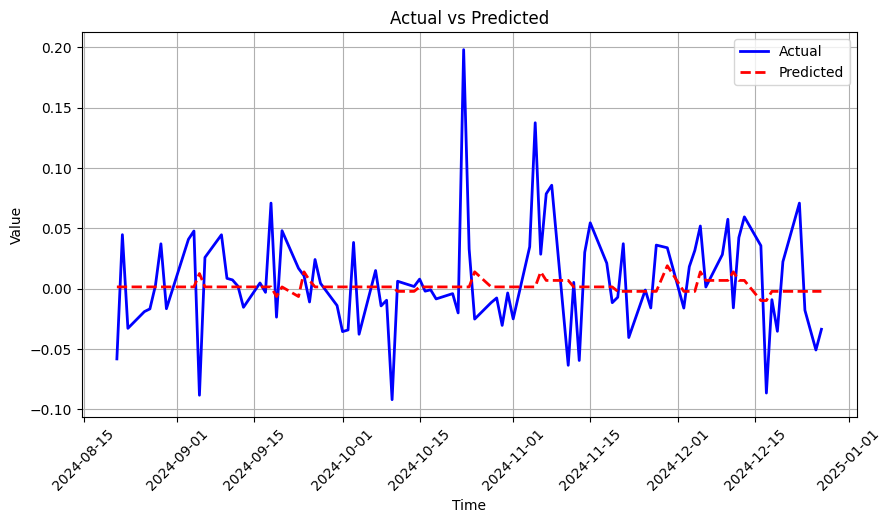

In [24]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests_xgb[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds_xgb[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# LSTM

In [25]:
# Class Definition
class LSTMRegressor(nn.Module):
    def __init__(self, base_params=None):
        super(LSTMRegressor, self).__init__()
        # Default hyperparameters
        defaults = {
            "input_dimension": stock_matrices['TSLA']['n_features'],
            "hidden_dimension": 16,
            "layer_dimension": 2,
            "output_dimension": 1,
            "dropout": 0.1,
            "lr": 1e-3,
            "num_epochs": 10, # number of forward passes
            "seq_len": 3, # how far back in time the model “looks” when making a prediction
        }
        
        # Merge user-supplied params with defaults
        if base_params is not None:
            defaults.update(base_params)
        self.params = defaults

        # Extract for convenience
        input_dim  = self.params["input_dimension"]
        hidden_dim = self.params["hidden_dimension"]
        num_layers = self.params["layer_dimension"]
        output_dim = self.params["output_dimension"]
        dropout    = self.params["dropout"]

        # --- Define LSTM layers ---
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        """
        x: (B, L, F)
        """
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])
            c0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])

        out, _ = self.lstm(x, (h0, c0))     # out: (B, L, H)
        out = self.fc(out[:, -1, :])        # use last timestep
        return out.squeeze(-1)

In [30]:
"""
Perform Time-Series CV on an LSTM model (same interface/returns as train_xgb).

Args:
    base_params: dict of hyperparameters for LSTMRegressor (e.g. {'seq_len':60,'num_epochs':20,'lr':1e-3})
    folds: list of dicts with 'train_idx' and 'test_idx' (from time series split)
    ticker: stock symbol key for feature_matrices
    feature_matrices: dict with entries like
        feature_matrices[ticker] = {'X': DataFrame/ndarray, 'y': Series/ndarray, 'dates': DatetimeIndex/array}

Returns:
    preds:  list[pd.Series]  predicted values on each test fold (indexed by test dates)
    tests:  list[pd.Series]  ground-truth values on each test fold (indexed by test dates)
    scores: list[float]      RMSE per fold
"""

def train_lstm(base_params=None, folds=None, ticker=None, feature_matrices=None):
    
    # --- Defaults values if base_params are not specified ---
    defaults = {"seq_len": 5, "num_epochs": 20, "lr": 1e-3}
    params = {**defaults, **(base_params or {})}
    L = int(params["seq_len"])
    epochs = int(params["num_epochs"])
    lr = float(params["lr"])

    # ---- Load data from feature_matrices (not stock_matrices) ----
    assert feature_matrices is not None and ticker in feature_matrices, "Bad feature_matrices/ticker"
    X_raw = feature_matrices[ticker]["X"]
    y_raw = feature_matrices[ticker]["y"]
    dates_all = pd.to_datetime(feature_matrices[ticker]["dates"])

    X_np = np.asarray(X_raw, dtype=np.float32)
    y_np = np.asarray(y_raw, dtype=np.float32)

    assert len(X_np) == len(y_np) == len(dates_all), "Length mismatch among X, y, dates"

    preds, tests, scores = [], [], []

    for fold in folds:
        train_idx, test_idx = fold["train_idx"], fold["test_idx"]
        X_train_full, y_train_full = X_np[train_idx], y_np[train_idx]
        X_test_full,  y_test_full  = X_np[test_idx],  y_np[test_idx]
        dates_test = dates_all[test_idx]

        # Skip too-short folds
        if len(X_train_full) <= L or len(X_test_full) <= L:
            preds.append(pd.Series([], dtype="float32"))
            tests.append(pd.Series([], dtype="float32"))
            scores.append(np.nan)
            continue

        # --- Initialize model/optim/criterion ---
        model = LSTMRegressor(params)          
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        # --- Training loop (windowed, single-step ahead) ---
        model.train()
        for epoch in range(epochs):
            total_loss = 0.0
            for i in range(len(X_train_full) - L):
                x_seq = torch.as_tensor(X_train_full[i:i+L], dtype=torch.float32).unsqueeze(0)  # [1, L, D]
                y_t   = torch.as_tensor([y_train_full[i+L]], dtype=torch.float32)               # [1]

                optimizer.zero_grad(set_to_none=True)
                y_pred = model(x_seq).view(-1)
                loss = criterion(y_pred, y_t)
                loss.backward()
                optimizer.step()
                total_loss += float(loss.detach())

            # print helper message every 5 epochs
            if (epoch + 1) % 5 == 0:
                avg = total_loss / max(len(X_train_full) - L, 1)
                print(f"[Fold {fold.get('fold','?')}] Epoch {epoch+1} | Train RMSE: {avg ** 0.5:.5f}")

        # --- Inference on test fold (same windowing) ---
        model.eval()
        preds_fold = []
        with torch.no_grad():
            for i in range(len(X_test_full) - L):
                x_seq = torch.as_tensor(X_test_full[i:i+L], dtype=torch.float32).unsqueeze(0)
                y_hat = model(x_seq).view(-1)[0].item()
                preds_fold.append(y_hat)

        # Align to dates (drop first L points because of the window)
        idx = pd.to_datetime(dates_test)[L:]
        y_test_seq = y_test_full[L:]
        y_pred_seq = np.asarray(preds_fold, dtype=np.float32)[:len(y_test_seq)]

        y_test_series = pd.Series(y_test_seq, index=idx)
        y_pred_series = pd.Series(y_pred_seq, index=idx)

        rmse = root_mean_squared_error(y_test_series, y_pred_series)
        print(f"[Fold {fold.get('fold','?')}] | Test RMSE: {rmse:.5f}")

        tests.append(y_test_series)
        preds.append(y_pred_series)
        scores.append(rmse)

        gc.collect()

    return preds, tests, scores

In [31]:
preds_lstm, tests_lstm, scores_lstm = train_lstm(folds=folds, ticker='TSLA', feature_matrices=stock_matrices)
print(f"CV Error: {np.mean(scores_lstm):.4f}")

[Fold 0] Epoch 5 | Train RMSE: 0.04141
[Fold 0] Epoch 10 | Train RMSE: 0.03849
[Fold 0] Epoch 15 | Train RMSE: 0.03559
[Fold 0] Epoch 20 | Train RMSE: 0.03115
[Fold 0] | Test RMSE: 0.03774
[Fold 1] Epoch 5 | Train RMSE: 0.04153
[Fold 1] Epoch 10 | Train RMSE: 0.03821
[Fold 1] Epoch 15 | Train RMSE: 0.03521
[Fold 1] Epoch 20 | Train RMSE: 0.03150
[Fold 1] | Test RMSE: 0.04352
[Fold 2] Epoch 5 | Train RMSE: 0.04078
[Fold 2] Epoch 10 | Train RMSE: 0.03707
[Fold 2] Epoch 15 | Train RMSE: 0.03324
[Fold 2] Epoch 20 | Train RMSE: 0.03072
[Fold 2] | Test RMSE: 0.04052
[Fold 3] Epoch 5 | Train RMSE: 0.03940
[Fold 3] Epoch 10 | Train RMSE: 0.03621
[Fold 3] Epoch 15 | Train RMSE: 0.03248
[Fold 3] Epoch 20 | Train RMSE: 0.02978
[Fold 3] | Test RMSE: 0.05128
[Fold 4] Epoch 5 | Train RMSE: 0.03893
[Fold 4] Epoch 10 | Train RMSE: 0.03622
[Fold 4] Epoch 15 | Train RMSE: 0.03239
[Fold 4] Epoch 20 | Train RMSE: 0.02943
[Fold 4] | Test RMSE: 0.05906
CV Error: 0.0464


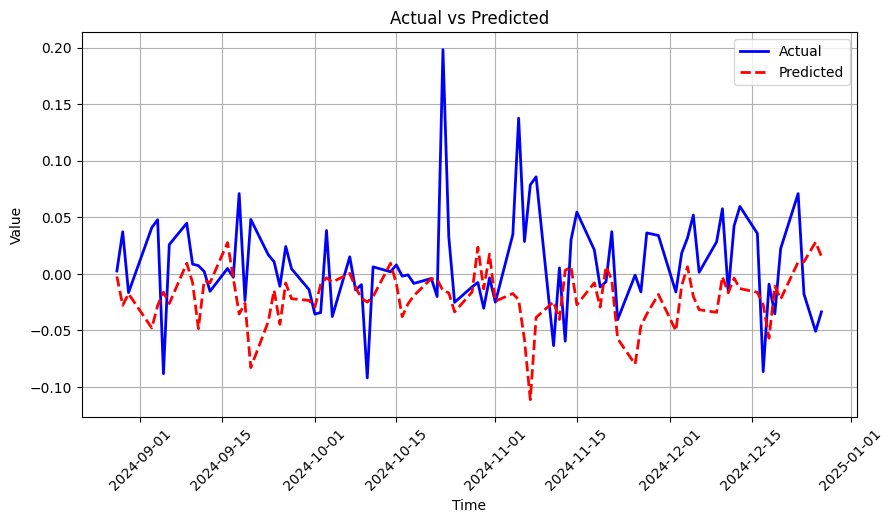

In [32]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests_lstm[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds_lstm[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()